# Sanger Sequencing Chromatogram Analysis
# Thomas C. Day
This notebook loads Sanger sequencing ".ab1" files, extracts the DNA sequence, fluorescence traces, and visualizes chromatogram peaks.

Requirements:
- Python
- Biopython
- Matplotlib

Workflow:
1. Install packages
2. Load .ab1 files
3. Extract sequences
4. Plot chromatograms

In [1]:
# Install dependencies (safe to re-run)
try:
    from Bio import SeqIO
except ImportError:
    !pip install biopython matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 23.6 MB/s eta 0:00:00


In [3]:
# Clone the GitHub repo
!git clone https://github.com/thomas-c-day/project-competition.git

import os
data_dir = "project-competition/data/ab1_files/30-1313077134_ab1/"

ab1_files = [f for f in os.listdir(data_dir) if f.endswith(".ab1")]

print("Found", len(ab1_files), "files")

fatal: destination path 'project-competition' already exists and is not an empty directory.
Found 15 files


In [ ]:
# Install some necessary packages:
%pip install biopython matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import items needed
from Bio import SeqIO
import matplotlib.pyplot as plt
import os

In [ ]:
# Get the sanger sequencing directory:
data_dir = "/home1/daythoma/03_Sequencing/data/raw_ab1/2026_03_27/"

# List files in the directory
ab1_files = [f for f in os.listdir(data_dir) if f.endswith(".ab1")]

print("Found", len(ab1_files), "AB1 files")
print(ab1_files)

Found 15 AB1 files
['AT03759587-Premixed.ab1', 'AT03759572-Premixed.ab1', 'AT03759573-Premixed.ab1', 'AT03759586-Premixed.ab1', 'AT03759571-Premixed.ab1', 'AT03759570-Premixed.ab1', 'AT03759580-Premixed.ab1', 'AT03759574-Premixed.ab1', 'AT03759581-Premixed.ab1', 'AT03759582-Premixed.ab1', 'AT03759589-Premixed.ab1', 'AT03759588-Premixed.ab1', 'AT03759578-Premixed.ab1', 'AT03759579-Premixed.ab1', 'AT03759590-Premixed.ab1']


AT03759587-Premixed.ab1
b'GATC'


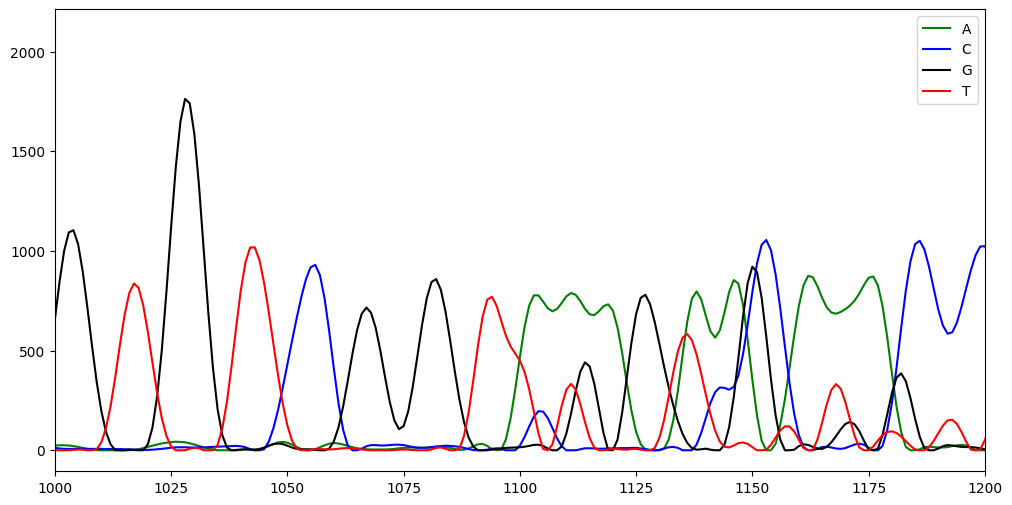

(3, 16, 28, 42, 54, 71, 79, 90, 103, 118, 131, 159, 166, 188, 197, 210, 223, 232, 239, 261, 270, 282, 294, 308, 321, 341, 360, 374, 385, 400, 414, 426, 435, 446, 454, 464, 474, 485, 493, 504, 512, 519, 529, 536, 547, 564, 574, 583, 593, 603, 620, 632, 644, 655, 664, 673, 684, 700, 710, 720, 729, 736, 750, 764, 773, 783, 800, 814, 826, 842, 854, 868, 879, 893, 905, 917, 930, 941, 952, 968, 977, 990, 1003, 1017, 1028, 1042, 1056, 1067, 1081, 1093, 1102, 1114, 1126, 1137, 1150, 1161, 1176, 1185, 1200, 1211, 1221, 1235, 1248, 1258, 1273, 1284, 1298, 1312, 1320, 1331, 1344, 1358, 1369, 1384, 1397, 1409, 1421, 1430, 1440, 1457, 1467, 1477, 1491, 1502, 1515, 1528, 1540, 1550, 1561, 1571, 1585, 1599, 1610, 1621, 1632, 1645, 1659, 1671, 1682, 1691, 1702, 1714, 1725, 1739, 1752, 1764, 1776, 1786, 1799, 1812, 1824, 1837, 1849, 1862, 1874, 1887, 1899, 1911, 1923, 1936, 1948, 1961, 1971, 1982, 1995, 2004, 2017, 2029, 2042, 2055, 2067, 2079, 2091, 2104, 2114, 2127, 2139, 2152, 2163, 2174, 2185, 2198

In [ ]:
# Load one particular file and inspect it:
file_no = 0;
file_path = os.path.join(data_dir, ab1_files[file_no])
record = SeqIO.read(file_path, "abi")
print(ab1_files[file_no])

# Find the chromatograms:
trace = record.annotations["abif_raw"]

# Print how the channels correspond to the base pairs:
print(trace["FWO_1"])

# Load each channel:
channels = [
    trace["DATA9"],
    trace["DATA10"],
    trace["DATA11"],
    trace["DATA12"]
]

# Assign channels to the proper base pair:
order = trace["FWO_1"].decode()
trace_dict = dict(zip(order, channels))
A = trace_dict["A"]
C = trace_dict["C"]
G = trace_dict["G"]
T = trace_dict["T"]

# Determine base pair assignment:
sequence = str(record.seq)
qualities = record.letter_annotations["phred_quality"]
positions = trace["PLOC2"]
BP = list(zip(positions, sequence, qualities))

# Show:
plt.figure(figsize=(12,6))
plt.plot(trace_dict["A"], label="A",color="Green")
plt.plot(trace_dict["C"], label="C",color="Blue")
plt.plot(trace_dict["G"], label="G",color="Black")
plt.plot(trace_dict["T"], label="T",color="Red")

# Overlay the basepair matches
for pos, base, q in BP:

    peak_height = max(
        A[pos],
        C[pos],
        G[pos],
        T[pos]
    )

    label = f"{base}\n{q}"

    #plt.text(pos, peak_height + 100, label, ha="center", fontsize=8)

plt.legend()
plt.xlim([1000,1200])
#plt.ylim([0,300])
plt.show()
print(positions)

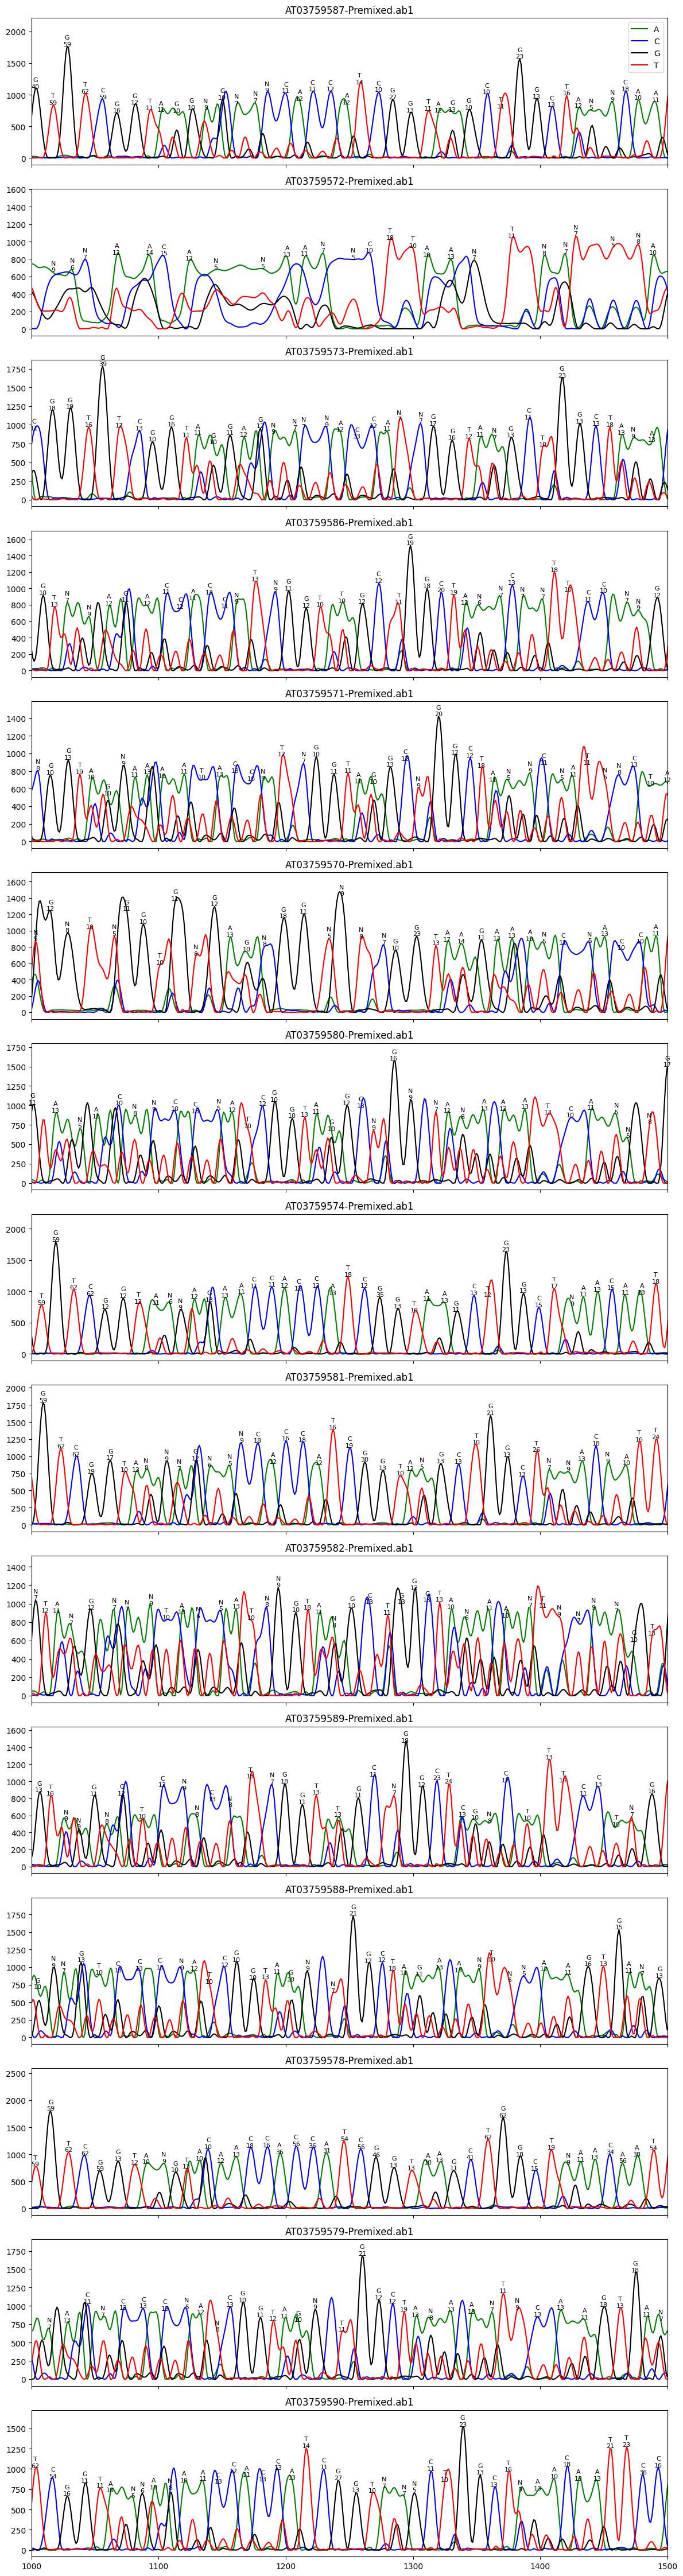

In [ ]:
# Show all the files in a vertical stack:
n_files = len(ab1_files)

fig, axes = plt.subplots(n_files, 1, figsize=(12, 3*n_files), sharex=True)

# If only one file, axes is not a list
if n_files == 1:
    axes = [axes]

xmin, xmax = [1000,1500]
for ax, file in zip(axes, ab1_files):

    file_path = os.path.join(data_dir, file)
    record = SeqIO.read(file_path, "abi")

    trace = record.annotations["abif_raw"]

    # Map channels correctly
    order = trace["FWO_1"].decode()
    channels = [
        trace["DATA9"],
        trace["DATA10"],
        trace["DATA11"],
        trace["DATA12"]
    ]
    trace_dict = dict(zip(order, channels))
    A = trace_dict["A"]
    C = trace_dict["C"]
    G = trace_dict["G"]
    T = trace_dict["T"]

    # Determine base pair assignment:
    sequence = str(record.seq)
    qualities = record.letter_annotations["phred_quality"]
    positions = trace["PLOC2"]
    BP = list(zip(positions, sequence, qualities))

    # Plot traces
    ax.plot(A, label="A",color="Green")
    ax.plot(C, label="C",color="Blue")
    ax.plot(G, label="G",color="Black")
    ax.plot(T, label="T",color="Red")

    # Overlay the basepair matches
    for pos, base, q in BP:
        # Only label bases within visible region
        if xmin <= pos <= xmax:
            peak_height = max(
                A[pos],
                C[pos],
                G[pos],
                T[pos]
            )
            label = f"{base}\n{q}"
            ax.text(pos, peak_height + 10, label, ha="center", fontsize=8)

    # Set the aesthetics
    ax.set_title(file)
    ax.set_xlim([xmin,xmax])

# Only show legend once
axes[0].legend()

plt.tight_layout()
plt.show()